In [54]:
import numpy as np
import pandas as pd
import datetime as dt
import yfinance as yf
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import statsmodels.api as sm
import statsmodels.tsa.stattools as ts
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

In [56]:
tickers = ["HDFCBANK.NS", "KOTAKBANK.NS"]

df = yf.download(tickers, start="2021-01-01", end="2026-01-01",auto_adjust=False,multi_level_index=False)['Adj Close']
df.columns = ['hdfcbank','kotakbank']
df.dropna(inplace=True)

# Normalize
df['hdfcbank_n'] = df['hdfcbank'] / df['hdfcbank'].iloc[0] * 100
df['kotakbank_n'] = df['kotakbank'] / df['kotakbank'].iloc[0] * 100

# Spread
df['spread'] = df['hdfcbank'] - df['kotakbank']

[*********************100%***********************]  2 of 2 completed


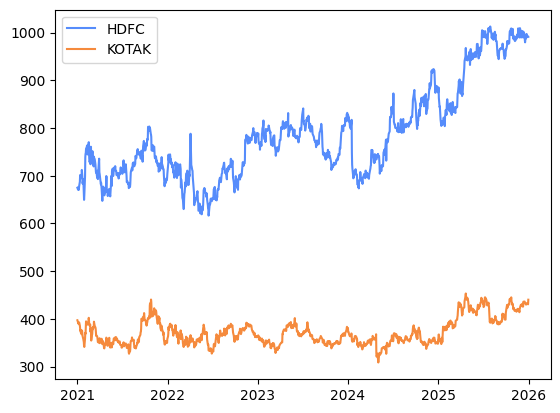

In [57]:
plt.plot(df['hdfcbank'], label='HDFC')
plt.plot(df['kotakbank'], label='KOTAK')
plt.legend()
plt.show()

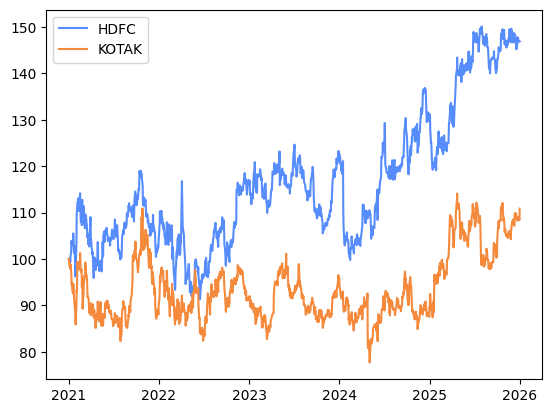

In [58]:
plt.plot(df['hdfcbank_n'], label='HDFC')
plt.plot(df['kotakbank_n'], label='KOTAK')
plt.legend()
plt.show()

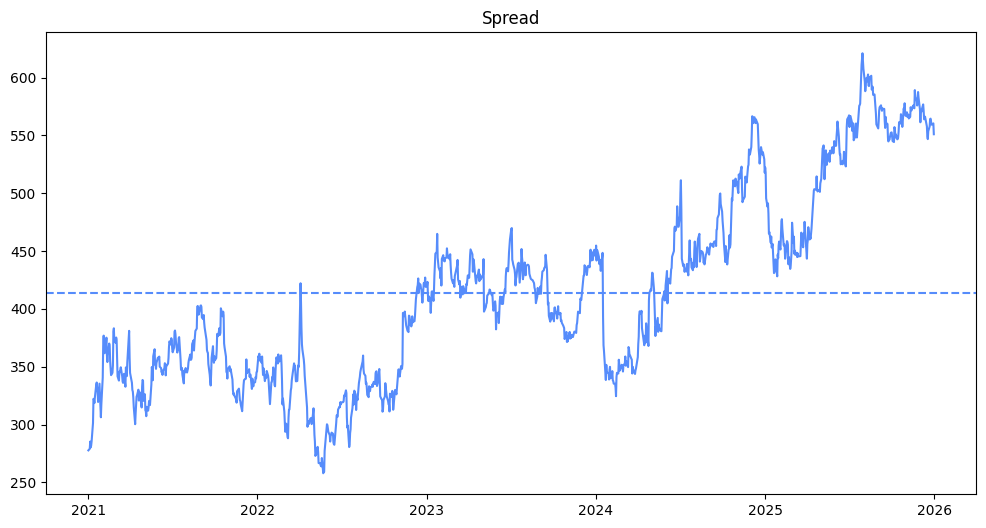

In [59]:
plt.figure(figsize=(12,6))
plt.plot(df['spread'])
plt.axhline(df['spread'].mean(), linestyle='--')
plt.title("Spread")
plt.show()

In [ ]:
le